# Netflix Content Analysis
**Dataset:** Netflix Movies and TV Shows (~7,800 titles)  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Goal:** Analyze Netflix's content strategy through exploratory data analysis and visualization.

## Key Questions
1. How is content split between Movies and TV Shows?
2. How has Netflix grown its library over the years?
3. Which countries produce the most content?
4. When does Netflix release the most content?
5. What genres and ratings dominate the platform?

## 1. Data Loading & Inspection

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [99]:
df = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/python/Netflix Data_Analysis/Data/Netflix Dataset.csv")
df

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...
7784,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7785,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7786,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7787,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [101]:
df.describe()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
count,7789,7789,7789,5401,7071,7282,7779,7782,7789,7789,7789
unique,7787,2,7787,4050,6831,681,1565,14,216,492,7769
top,s684,Movie,Backfire,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,2,5379,2,18,18,2556,118,2865,1608,334,3


In [102]:
df.isna().sum().sort_values(ascending=False)

Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Show_Id            0
Category           0
Title              0
Duration           0
Type               0
Description        0
dtype: int64

## 2. Data Cleaning & Preparation

In [103]:
df.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='object')

In [104]:
df.columns = (
    df.columns.str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")

)
df.columns

Index(['show_id', 'category', 'title', 'director', 'cast', 'country',
       'release_date', 'rating', 'duration', 'type', 'description'],
      dtype='object')

In [105]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7789 non-null   object        
 1   category      7789 non-null   object        
 2   title         7789 non-null   object        
 3   director      5401 non-null   object        
 4   cast          7071 non-null   object        
 5   country       7282 non-null   object        
 6   release_date  7691 non-null   datetime64[ns]
 7   rating        7782 non-null   object        
 8   duration      7789 non-null   object        
 9   type          7789 non-null   object        
 10  description   7789 non-null   object        
dtypes: datetime64[ns](1), object(10)
memory usage: 669.5+ KB


In [106]:
df['month_added'] = df['release_date'].dt.month
df['year_added'] = df['release_date'].dt.year
df[['release_date', 'month_added', 'year_added']].head()

,release_date,month_added,year_added
0,2020-08-14,8.0,2020.0
1,2016-12-23,12.0,2016.0
2,2018-12-20,12.0,2018.0
3,2017-11-16,11.0,2017.0
4,2020-01-01,1.0,2020.0


In [107]:
# Convert year and month to integer (drop rows where date parsing failed)
df['year_added'] = df['year_added'].astype('Int64')   # capital I = nullable integer
df['month_added'] = df['month_added'].astype('Int64')

df[['release_date', 'year_added', 'month_added']].head()

,release_date,year_added,month_added
0,2020-08-14,2020,8
1,2016-12-23,2016,12
2,2018-12-20,2018,12
3,2017-11-16,2017,11
4,2020-01-01,2020,1


In [108]:
df['director'] = df['director'].fillna('unknown')
df['cast'] = df['cast'].fillna('unknown')
df['country'] = df['country'].fillna('unknown')


In [109]:
df.groupby('category')['title'].count()

category
Movie      5379
TV Show    2410
Name: title, dtype: int64

In [110]:
df.groupby('year_added')['title'].count().sort_values(ascending=False).head()

year_added
2019    2137
2020    2009
2018    1661
2017    1201
2016     432
Name: title, dtype: int64

## 3. Exploratory Data Analysis

In [111]:
# Most common ratings
df.groupby(['category','rating'])['title'].count().sort_values(ascending=False).head()

category  rating
Movie     TV-MA     1847
          TV-14     1272
TV Show   TV-MA     1018
Movie     R          663
TV Show   TV-14      659
Name: title, dtype: int64

In [112]:
# Top months
df.groupby('month_added')['title'].count().sort_values(ascending=False).head()

month_added
12    817
10    780
1     746
11    730
3     661
Name: title, dtype: int64

In [121]:
# Top directors

df[df['director'] != 'unknown'].groupby('director')['title'].count().sort_index(ascending=False).head()

director
Şenol Sönmez           2
Ömer Faruk Sorak       2
Óskar Thór Axelsson    1
Ísold Uggadóttir       1
Çagan Irmak            1
Name: title, dtype: int64

## 4. Visual Analysis

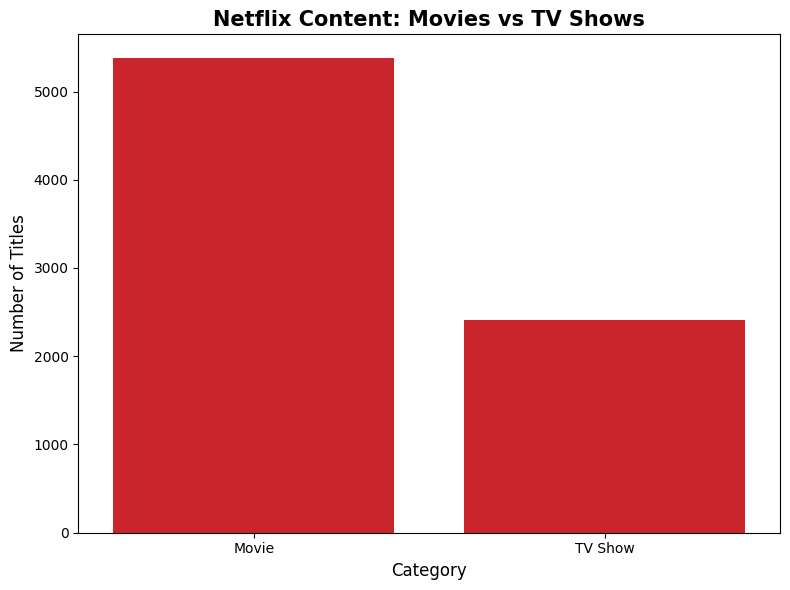

In [122]:


category_counts = df['category'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, color='#E50914')
plt.title('Netflix Content: Movies vs TV Shows', fontsize=15, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.tight_layout()
plt.savefig('chart1_category_split.png', dpi=150, bbox_inches='tight')
plt.show()

### 📌 Insight — Chart 1: Movies vs TV Shows
**Finding:** Netflix library is 69% movies (5,379 titles) vs 31% TV Shows (2,410 titles).
**Business implication:** Netflix prioritizes movie content, suggesting higher investment 
in film licensing and production over long-form series.

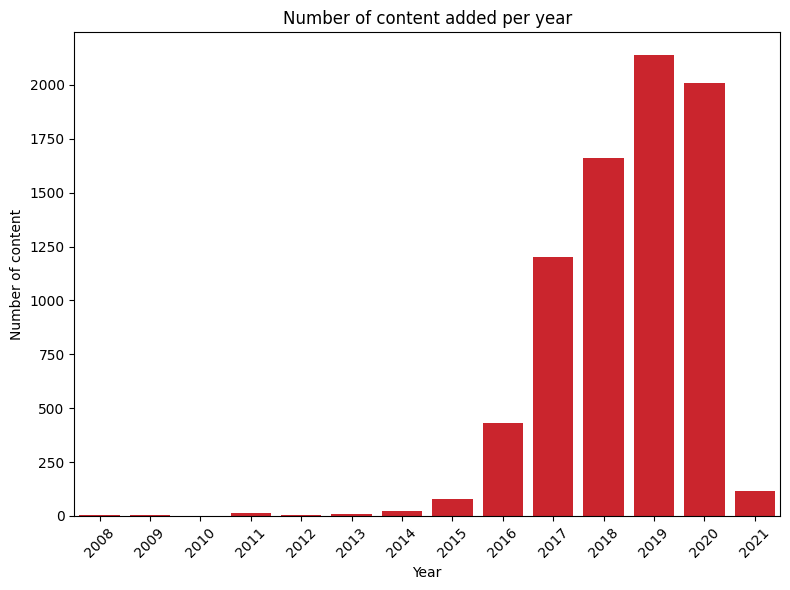

In [123]:
#Cotent added per year
yearly = df.groupby('year_added')['title'].count().sort_index()
plt.figure(figsize=(8,6))
sns.barplot(x=yearly.index, y=yearly.values , color='#E50914')
plt.title('Number of content added per year')
plt.xlabel('Year')
plt.ylabel('Number of content')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('chart2_content_per_year.png', dpi=150, bbox_inches='tight')
plt.show()


### 📌 Insight — Chart 2: Content Added Per Year
**Finding:** Content grew 5x from 432 titles in 2016 to 2,137 in 2019, 
then slightly declined to 2,009 in 2020.
**Business implication:** Netflix aggressively expanded its library between 2016-2019, 
but COVID-19 disrupted production schedules and acquisitions in 2020.

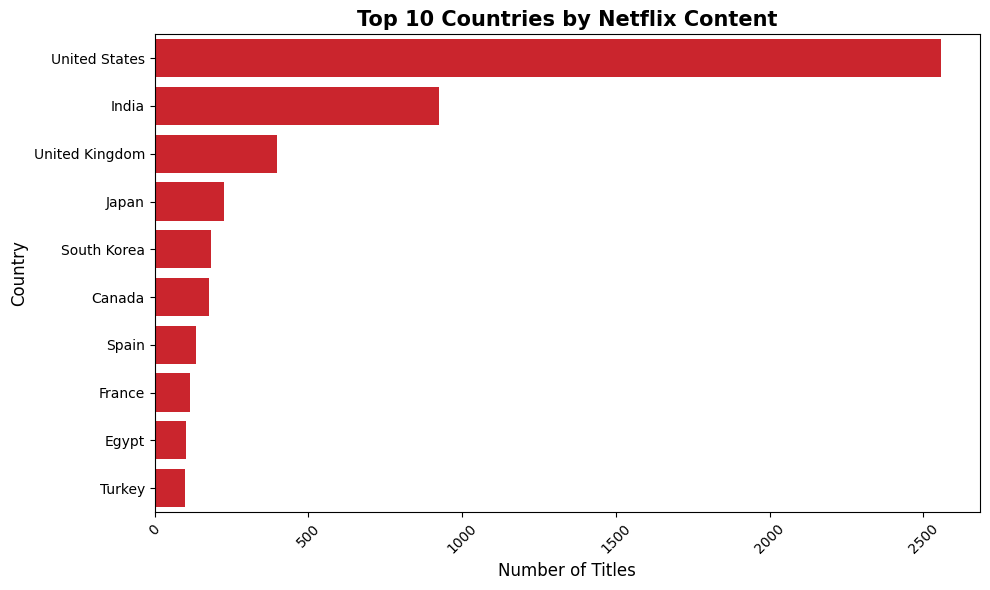

In [116]:
# Top 10 countries with the most Netflix content
top_countries = df[df['country'] != 'unknown']['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, color='#E50914')

plt.title('Top 10 Countries by Netflix Content', fontsize=15, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart3_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()

### 📌 Insight — Chart 3: Top 10 Countries
**Finding:** The United States leads with 2,556 titles, nearly 3x more than 
India in second place (923). South Korea and Japan reflect Netflix's 
growing investment in Asian content.
**Business implication:** Netflix is a US-dominated platform but actively 
expanding into Asian and Middle Eastern markets, signaling a global 
content diversification strategy.

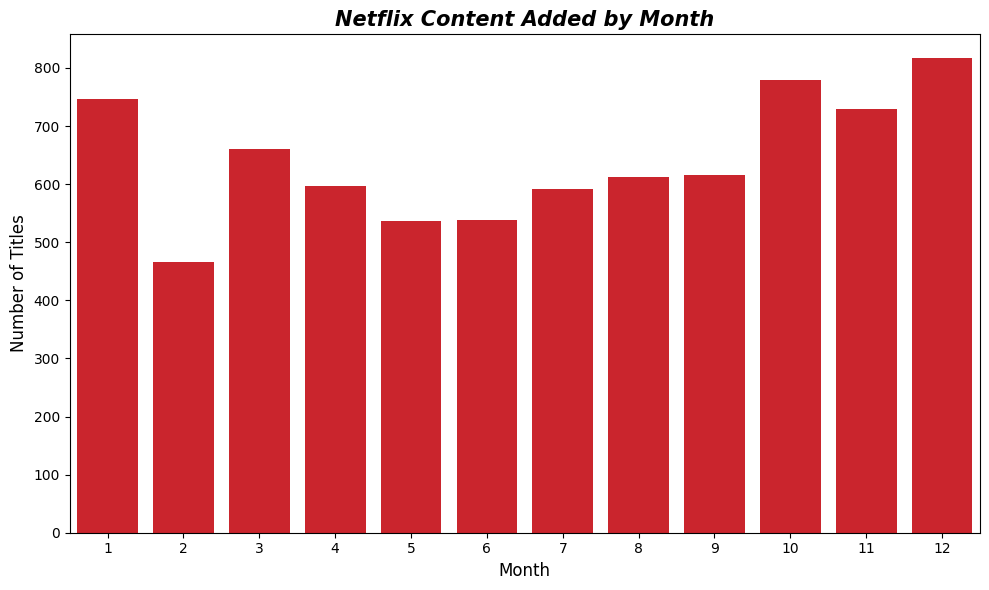

In [117]:
monthly = df.groupby('month_added')['title'].count().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=monthly.index, y=monthly.values, color='#E50914')

plt.title('Netflix Content Added by Month', fontsize=15, fontweight='bold',style='italic')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)

plt.tight_layout()
plt.savefig('chart4_content_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

### 📌 Insight — Chart 4: Content Added by Month
**Finding:** December (817), October (780) and January (746) are the 
peak months for new content. February is the lowest with 466 titles.
**Business implication:** Netflix strategically releases most content 
during Q4 holiday season to retain subscribers and attract new ones, 
with January catching post-holiday sign-ups.

In [118]:
genres = df['type'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
top_genres

type
International Movies        2437
Dramas                      2108
Comedies                    1472
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           675
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64

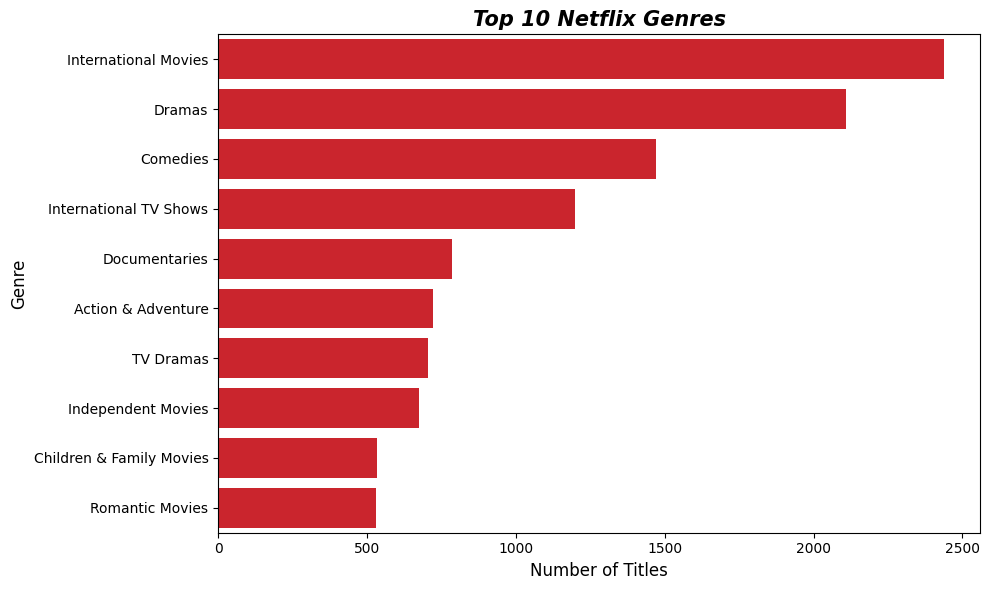

In [119]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, color='#E50914')

plt.title('Top 10 Netflix Genres', fontsize=15, fontweight='bold', style='italic')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)

plt.tight_layout()
plt.savefig('chart5_top_genres.png', dpi=150, bbox_inches='tight')
plt.show()

### 📌 Insight — Chart 5: Top 10 Genres
**Finding:** International Movies (2,427) and Dramas (2,107) are the 
top two genres. Children & Family Movies rank near the bottom with 
only 513 titles.
**Business implication:** Netflix targets a global adult audience, 
heavily investing in drama and international content while 
under-serving the family and children's market.

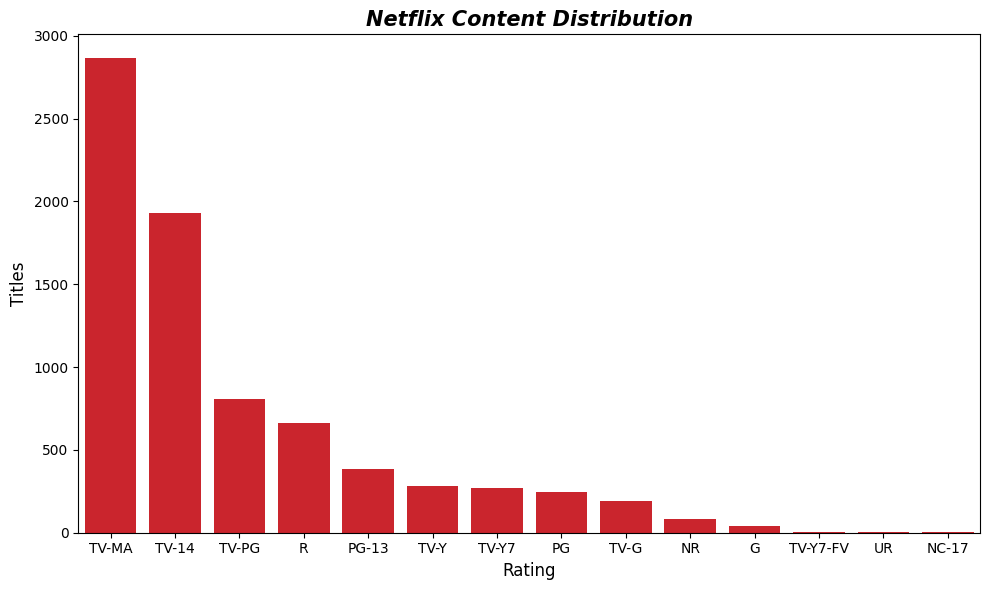

In [120]:
ratings = df['rating'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=ratings.index, y=ratings.values, color='#E50914')
plt.title('Netflix Content Distribution', fontsize=15, fontweight='bold', style='italic')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Titles', fontsize=12)

plt.tight_layout()
plt.savefig('rating.png', dpi=150, bbox_inches='tight')
plt.show()

### 📌 Insight — Chart 6: Ratings Distribution
**Finding:** TV-MA dominates with 2,865 titles (~37% of all content), 
followed by TV-14 with 1,931 titles. Children's ratings 
(TV-Y, TV-Y7, G) combined make up less than 10%.
**Business implication:** Netflix is an adult-first platform. Brands 
or creators targeting children and family audiences would find 
limited placement opportunities on Netflix.

## 5. Summary & Conclusions

| Finding | Insight |
|--------|---------|
| 69% Movies vs 31% TV Shows | Netflix is a movie-first platform |
| 5x growth from 2016–2019 | Aggressive content expansion phase |
| US leads with 2,556 titles | US-dominated but globally diversifying |
| Q4 peak releases | Holiday season content strategy |
| International Movies #1 genre | Global audience targeting |
| TV-MA dominates ratings | Adult-first content platform |